In [ ]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv('ola_driver_scaler.csv')

# basic checks
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


#Data Cleaning

In [ ]:
# drop useless column
df.drop(columns=['Unnamed: 0'], inplace=True)

# convert dates
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'], format='%d/%m/%y')
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y')

# check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   MMM-YY                19104 non-null  datetime64[ns]
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  float64       
 4   City                  19104 non-null  object        
 5   Education_Level       19104 non-null  int64         
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  int64         
 10  Grade                 19104 non-null  int64         
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
dtypes: datetime64[ns

In [ ]:
#Validate duplicates
df['Driver_ID'].nunique()
df.shape

(19104, 13)

In [ ]:
df['Driver_ID'].nunique()

2381

In [ ]:
#Creating target value
df['target'] = df['LastWorkingDate'].notnull().astype(int)
df['target'].value_counts()

,count
target,
0,17488
1,1616


#EDA1

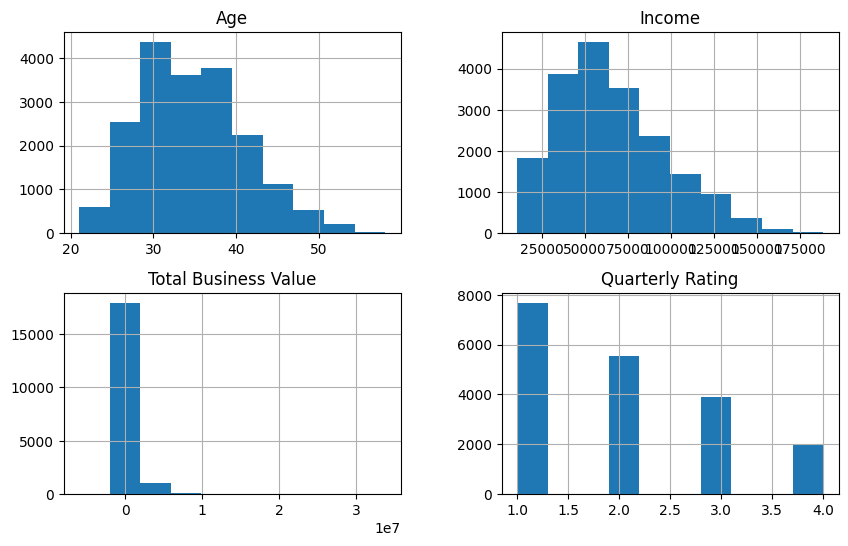

In [ ]:
#Numeric distributions
import matplotlib.pyplot as plt

df[['Age','Income','Total Business Value','Quarterly Rating']].hist(figsize=(10,6))
plt.show()

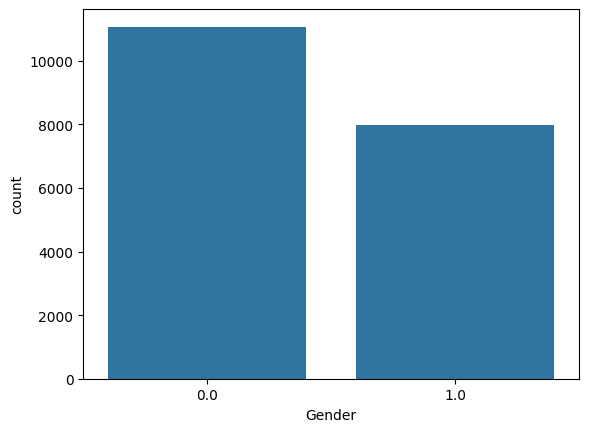

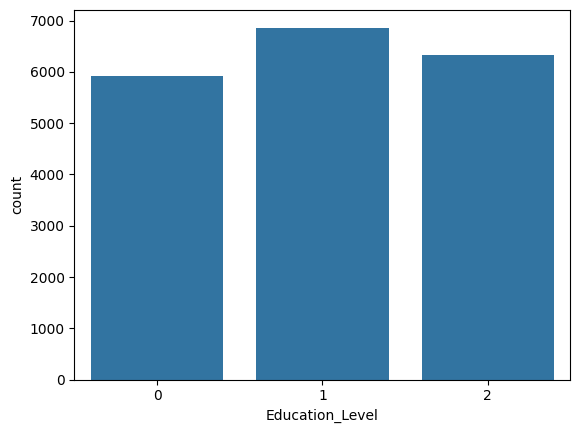

In [ ]:
#Categorical distributions
import seaborn as sns

sns.countplot(x='Gender', data=df)
plt.show()

sns.countplot(x='Education_Level', data=df)
plt.show()

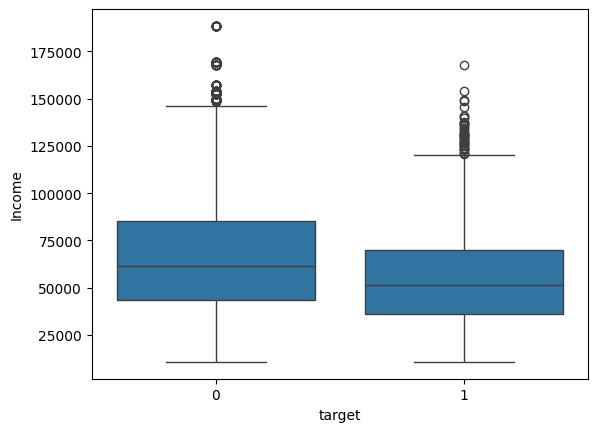

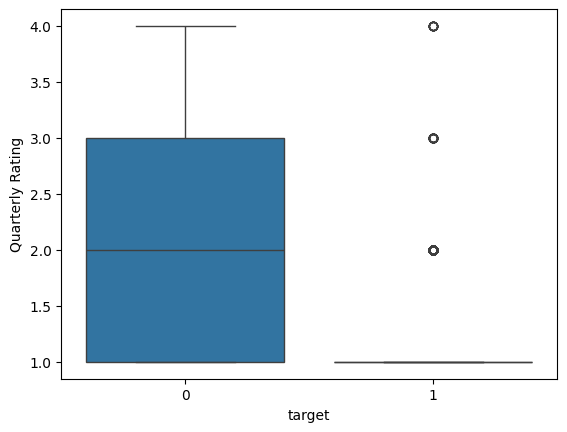

In [ ]:
#Target vs key variables
sns.boxplot(x='target', y='Income', data=df)
plt.show()

sns.boxplot(x='target', y='Quarterly Rating', data=df)
plt.show()

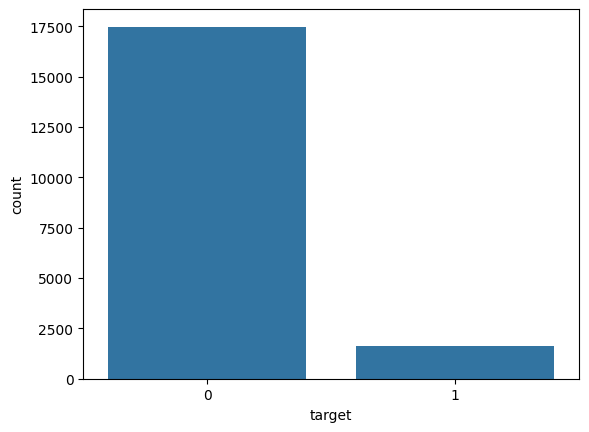

In [ ]:
#Target distribution plot (important)
sns.countplot(x='target', data=df)
plt.show()

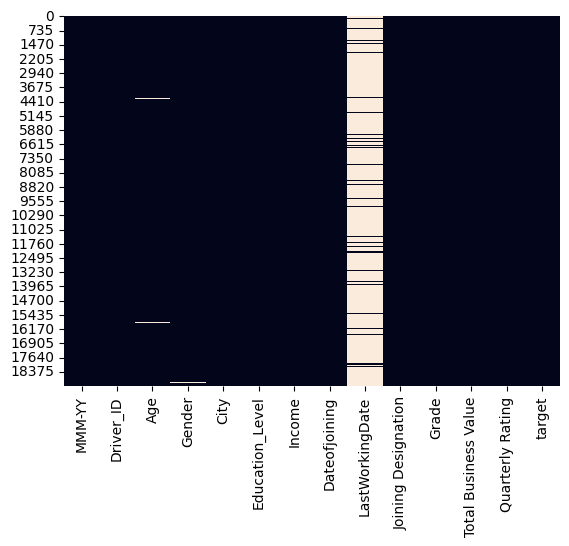

In [ ]:
#Check missing values visually (important for report)
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.show()

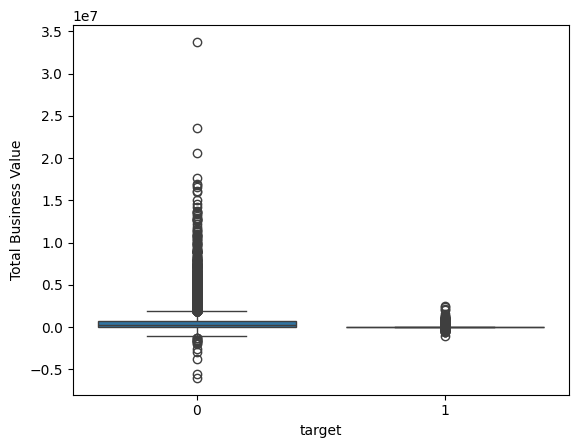

In [ ]:
#One more key bivariate (recommended)
sns.boxplot(x='target', y='Total Business Value', data=df)
plt.show()

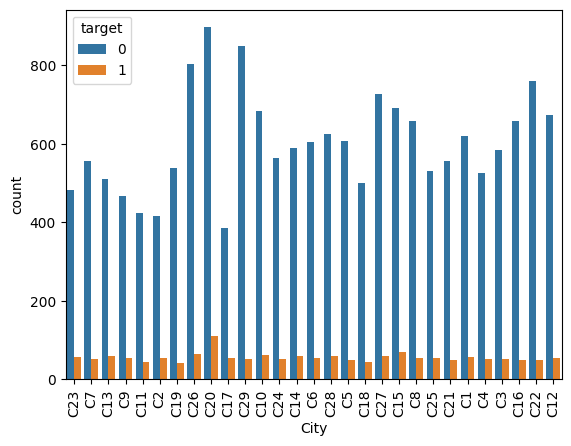

In [ ]:
#City vs Target
sns.countplot(x='City', hue='target', data=df)
plt.xticks(rotation=90)
plt.show()

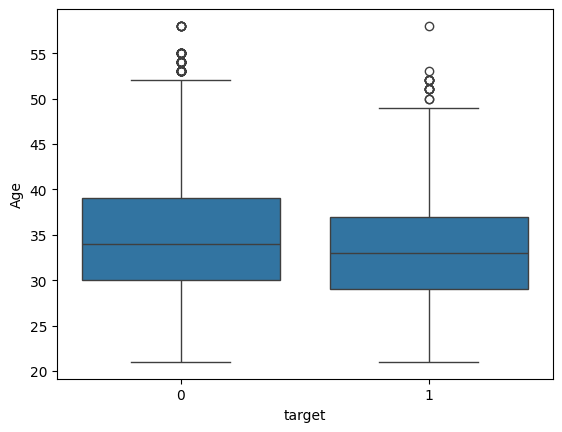

In [ ]:
#Age vs Target
sns.boxplot(x='target', y='Age', data=df)
plt.show()

#Aggregation

In [ ]:
#Sort data
df = df.sort_values(by=['Driver_ID', 'MMM-YY'])

In [ ]:
#aggregation
driver_df = df.sort_values(by=['Driver_ID', 'MMM-YY']).groupby('Driver_ID').agg({
    'Age': 'last',
    'Gender': 'last',
    'City': 'last',
    'Education_Level': 'last',
    'Income': ['first', 'last'],
    'Dateofjoining': 'first',
    'LastWorkingDate': 'last',
    'Joining Designation': 'first',
    'Grade': 'last',
    'Total Business Value': 'sum',
    'Quarterly Rating': ['first', 'last'],
    'target': 'max'
})

In [ ]:
#Flatten columns
driver_df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in driver_df.columns]

In [ ]:
driver_df = driver_df.reset_index()

In [ ]:
driver_df.shape

(2381, 15)

In [ ]:
driver_df['Driver_ID'].nunique()

2381

In [ ]:
driver_df.head()

,Driver_ID,Age_last,Gender_last,City_last,Education_Level_last,Income_first,Income_last,Dateofjoining_first,LastWorkingDate_last,Joining Designation_first,Grade_last,Total Business Value_sum,Quarterly Rating_first,Quarterly Rating_last,target_max
0,1,28.0,0.0,C23,2,57387,57387,2018-12-24,2019-11-03,1,1,1715580,2,2,1
1,2,31.0,0.0,C7,2,67016,67016,2020-06-11,NaT,2,2,0,1,1,0
2,4,43.0,0.0,C13,2,65603,65603,2019-07-12,2020-04-27,2,2,350000,1,1,1
3,5,29.0,0.0,C9,0,46368,46368,2019-09-01,2019-07-03,1,1,120360,1,1,1
4,6,31.0,1.0,C11,1,78728,78728,2020-07-31,NaT,3,3,1265000,1,2,0


#Feature Engineering

In [ ]:
#Income increase flag
driver_df['income_increase'] = (driver_df['Income_last'] > driver_df['Income_first']).astype(int)

In [ ]:
#Rating increase flag
driver_df['rating_increase'] = (driver_df['Quarterly Rating_last'] > driver_df['Quarterly Rating_first']).astype(int)

In [ ]:
#Rename target (clean)
driver_df.rename(columns={'target_max': 'target'}, inplace=True)

In [ ]:
#Quick check
driver_df[['Income_first','Income_last','income_increase',
           'Quarterly Rating_first','Quarterly Rating_last','rating_increase']].head()

,Income_first,Income_last,income_increase,Quarterly Rating_first,Quarterly Rating_last,rating_increase
0,57387,57387,0,2,2,0
1,67016,67016,0,1,1,0
2,65603,65603,0,1,1,0
3,46368,46368,0,1,1,0
4,78728,78728,0,1,2,1


In [ ]:
#Check missing values
driver_df.isnull().sum()

,0
Driver_ID,0
Age_last,0
Gender_last,0
City_last,0
Education_Level_last,0
Income_first,0
Income_last,0
Dateofjoining_first,0
LastWorkingDate_last,765
Joining Designation_first,0


In [ ]:
#Prepare data for KNN
from sklearn.impute import KNNImputer

# select numeric columns only
num_cols = driver_df.select_dtypes(include=['int64', 'float64']).columns

# remove target column
num_cols = num_cols.drop('target')

X_num = driver_df[num_cols]

In [ ]:
#Apply KNN
imputer = KNNImputer(n_neighbors=5)

X_imputed = imputer.fit_transform(X_num)

X_imputed = pd.DataFrame(X_imputed, columns=num_cols)

In [ ]:
driver_df[num_cols] = X_imputed

#Encoding (categorical)

In [ ]:
#One-hot encoding
driver_df = pd.get_dummies(driver_df, columns=['City_last'], drop_first=True)

In [ ]:
driver_df.shape

(2381, 44)

In [ ]:
driver_df.head()

,Driver_ID,Age_last,Gender_last,Education_Level_last,Income_first,Income_last,Dateofjoining_first,LastWorkingDate_last,Joining Designation_first,Grade_last,...,City_last_C27,City_last_C28,City_last_C29,City_last_C3,City_last_C4,City_last_C5,City_last_C6,City_last_C7,City_last_C8,City_last_C9
0,1.0,28.0,0.0,2.0,57387.0,57387.0,2018-12-24,2019-11-03,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,2.0,31.0,0.0,2.0,67016.0,67016.0,2020-06-11,NaT,2.0,2.0,...,False,False,False,False,False,False,False,True,False,False
2,4.0,43.0,0.0,2.0,65603.0,65603.0,2019-07-12,2020-04-27,2.0,2.0,...,False,False,False,False,False,False,False,False,False,False
3,5.0,29.0,0.0,0.0,46368.0,46368.0,2019-09-01,2019-07-03,1.0,1.0,...,False,False,False,False,False,False,False,False,False,True
4,6.0,31.0,1.0,1.0,78728.0,78728.0,2020-07-31,NaT,3.0,3.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
driver_df.drop(columns=[
    'Driver_ID',
    'Dateofjoining_first',
    'LastWorkingDate_last'
], inplace=True)

In [ ]:
driver_df.shape

(2381, 41)

#Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = driver_df.drop(columns=['target'])
y = driver_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

,proportion
target,
1,0.679245
0,0.320755


distribution flipped → something went wrong.

In [ ]:
driver_df['target'].value_counts(normalize=True)

,proportion
target,
1,0.678706
0,0.321294


This is incorrect. The target got corrupted.

In [ ]:
driver_df.columns

Index(['Age_last', 'Gender_last', 'Education_Level_last', 'Income_first',
       'Income_last', 'Joining Designation_first', 'Grade_last',
       'Total Business Value_sum', 'Quarterly Rating_first',
       'Quarterly Rating_last', 'target', 'income_increase', 'rating_increase',
       'City_last_C10', 'City_last_C11', 'City_last_C12', 'City_last_C13',
       'City_last_C14', 'City_last_C15', 'City_last_C16', 'City_last_C17',
       'City_last_C18', 'City_last_C19', 'City_last_C2', 'City_last_C20',
       'City_last_C21', 'City_last_C22', 'City_last_C23', 'City_last_C24',
       'City_last_C25', 'City_last_C26', 'City_last_C27', 'City_last_C28',
       'City_last_C29', 'City_last_C3', 'City_last_C4', 'City_last_C5',
       'City_last_C6', 'City_last_C7', 'City_last_C8', 'City_last_C9'],
      dtype='object')

In [ ]:
#Recreate driver_df from scratch
driver_df = df.sort_values(by=['Driver_ID', 'MMM-YY']).groupby('Driver_ID').agg({
    'Age': 'last',
    'Gender': 'last',
    'City': 'last',
    'Education_Level': 'last',
    'Income': ['first', 'last'],
    'Dateofjoining': 'first',
    'LastWorkingDate': 'last',
    'Joining Designation': 'first',
    'Grade': 'last',
    'Total Business Value': 'sum',
    'Quarterly Rating': ['first', 'last']
}).reset_index()

In [ ]:
driver_df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in driver_df.columns]

In [ ]:
driver_df['target'] = driver_df['LastWorkingDate_last'].notnull().astype(int)

In [ ]:
driver_df['target'].value_counts(normalize=True)

,proportion
target,
1,0.678706
0,0.321294


dataset is NOT imbalanced the way we assumed earlier

#Feature Engineering (redo)

In [ ]:
#Income increase
driver_df['income_increase'] = (driver_df['Income_last'] > driver_df['Income_first']).astype(int)

In [ ]:
#Rating increase
driver_df['rating_increase'] = (driver_df['Quarterly Rating_last'] > driver_df['Quarterly Rating_first']).astype(int)

In [ ]:
#Check
driver_df[['Income_first','Income_last','income_increase',
           'Quarterly Rating_first','Quarterly Rating_last','rating_increase']].head()

,Income_first,Income_last,income_increase,Quarterly Rating_first,Quarterly Rating_last,rating_increase
0,57387,57387,0,2,2,0
1,67016,67016,0,1,1,0
2,65603,65603,0,1,1,0
3,46368,46368,0,1,1,0
4,78728,78728,0,1,2,1


In [ ]:
#encoding
driver_df = pd.get_dummies(driver_df, columns=['City_last'], drop_first=True)

In [ ]:
driver_df.shape

(2381, 44)

In [ ]:
df.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,target
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,0
1,2019-01-02,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2,0
2,2019-01-03,1,28.0,0.0,C23,2,57387,2018-12-24,2019-11-03,1,1,0,2,1
3,2020-01-11,2,31.0,0.0,C7,2,67016,2020-06-11,NaT,2,2,0,1,0
4,2020-01-12,2,31.0,0.0,C7,2,67016,2020-06-11,NaT,2,2,0,1,0


In [ ]:
driver_df.columns

Index(['Driver_ID_', 'Age_last', 'Gender_last', 'Education_Level_last',
       'Income_first', 'Income_last', 'Dateofjoining_first',
       'LastWorkingDate_last', 'Joining Designation_first', 'Grade_last',
       'Total Business Value_sum', 'Quarterly Rating_first',
       'Quarterly Rating_last', 'target', 'income_increase', 'rating_increase',
       'City_last_C10', 'City_last_C11', 'City_last_C12', 'City_last_C13',
       'City_last_C14', 'City_last_C15', 'City_last_C16', 'City_last_C17',
       'City_last_C18', 'City_last_C19', 'City_last_C2', 'City_last_C20',
       'City_last_C21', 'City_last_C22', 'City_last_C23', 'City_last_C24',
       'City_last_C25', 'City_last_C26', 'City_last_C27', 'City_last_C28',
       'City_last_C29', 'City_last_C3', 'City_last_C4', 'City_last_C5',
       'City_last_C6', 'City_last_C7', 'City_last_C8', 'City_last_C9'],
      dtype='object')

In [ ]:
driver_df.rename(columns={'Driver_ID_': 'Driver_ID'}, inplace=True)

In [ ]:
#dropping columns
driver_df.drop(columns=[
    'Driver_ID',
    'Dateofjoining_first',
    'LastWorkingDate_last'
], inplace=True)

In [ ]:
driver_df.shape

(2381, 41)

In [ ]:
driver_df['target'].value_counts(normalize=True)

,proportion
target,
1,0.678706
0,0.321294


#Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = driver_df.drop(columns=['target'])
y = driver_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
target,
1,0.678571
0,0.321429


In [ ]:
y_test.value_counts(normalize=True)

,proportion
target,
1,0.679245
0,0.320755


In [ ]:
#Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(1904, 40)

In [ ]:
X_test_scaled.shape

(477, 40)

#Modeling

In [ ]:
#Model 1: Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

In [ ]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[ 93  60]
 [ 30 294]]
              precision    recall  f1-score   support

           0       0.76      0.61      0.67       153
           1       0.83      0.91      0.87       324

    accuracy                           0.81       477
   macro avg       0.79      0.76      0.77       477
weighted avg       0.81      0.81      0.81       477

ROC-AUC: 0.844841846203502


Random Forest — Key Takeaways:

Accuracy: ~81%

ROC-AUC: 0.84 (strong)

Class-wise

Class 1 (churn):

Recall = 0.91 → very good

Class 0 (non-churn):

Recall = 0.61 → weaker


Model favors predicting churn (acceptable for business)

#Boosting Model

In [ ]:
#Use Gradient Boosting


from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
y_prob_gb = gb.predict_proba(X_test_scaled)[:,1]

In [ ]:
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

[[ 98  55]
 [ 23 301]]
              precision    recall  f1-score   support

           0       0.81      0.64      0.72       153
           1       0.85      0.93      0.89       324

    accuracy                           0.84       477
   macro avg       0.83      0.78      0.80       477
weighted avg       0.83      0.84      0.83       477

ROC-AUC: 0.8561284596142985


Random Forest:
Accuracy: 0.81
ROC-AUC: 0.844
Class 0 recall: 0.61
Class 1 recall: 0.91
Gradient Boosting:

Accuracy: 0.84
ROC-AUC: 0.856
Class 0 recall: 0.64 (better)
Class 1 recall: 0.93 (better)

Conclusion

Gradient Boosting is better

Higher ROC-AUC
Better balance across classes

#Feature Importance (from best model = Gradient Boosting)

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
9,Quarterly Rating_last,0.508710
7,Total Business Value_sum,0.181259
5,Joining Designation_first,0.076518
8,Quarterly Rating_first,0.036957
4,Income_last,0.036555
0,Age_last,0.031648
3,Income_first,0.027546
6,Grade_last,0.018069
11,rating_increase,0.013364
31,City_last_C28,0.007877


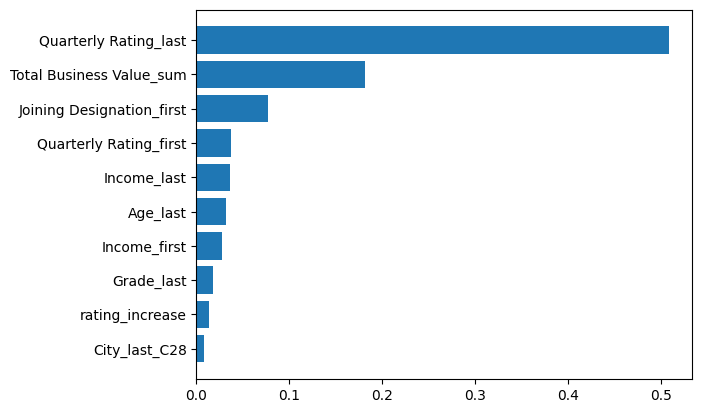

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()
plt.show()

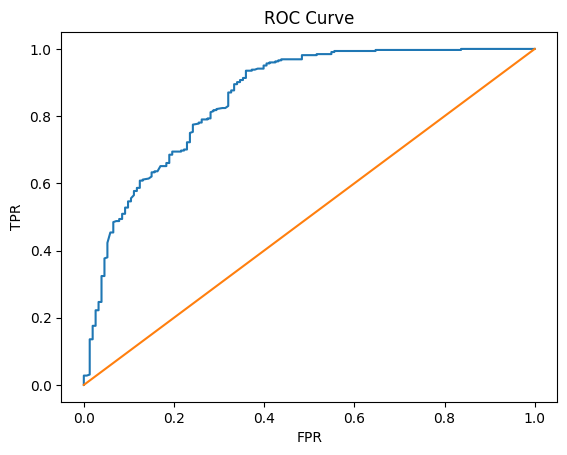

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.show()

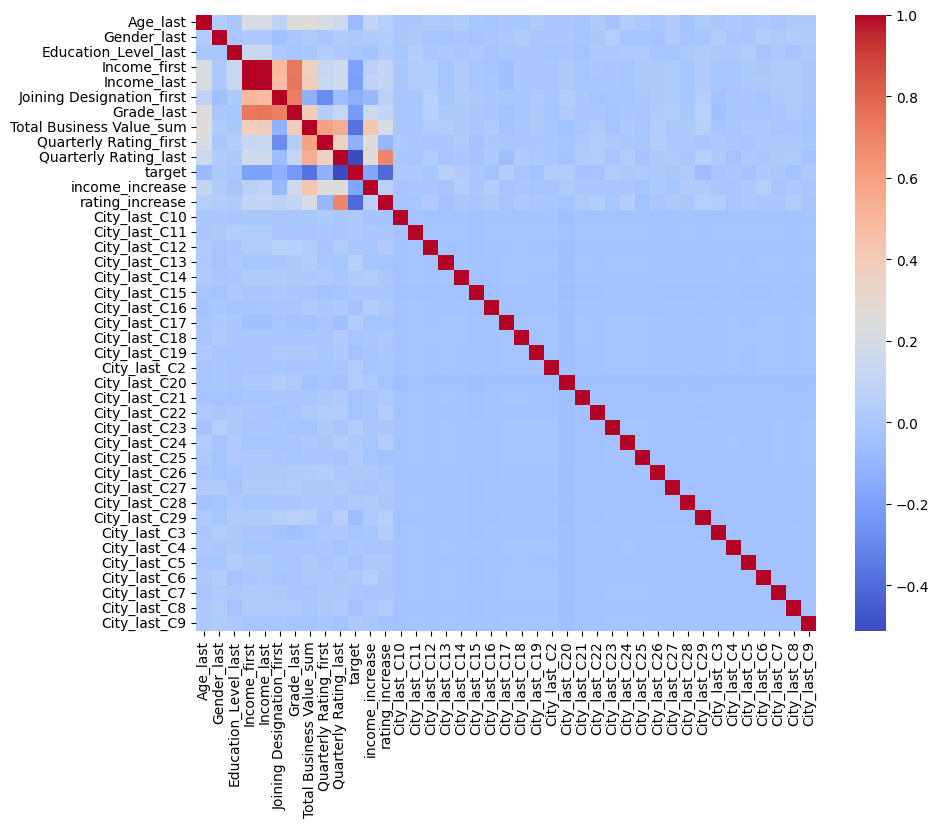

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(driver_df.corr(), cmap='coolwarm')
plt.show()